In [8]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from scipy.special import sici
from scipy.interpolate import interp1d

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

def mm(cc, cx, xx, fx=0.1):
    return (1-fx)**2 *cc+fx*(1-fx)*cx+fx**2 * xx

----
Plots for introduction: transfer functions and $P$ linear (from _match_kJ_)

In [9]:
h = 0.67810
_H0_ = 3.336e-04 * h
_ev_to_HO_ = 1.56e29 / _H0_
common_settings = {'omega_b': 0.0223828, 'h': h, 'z_reio': 7.6711, 'YHe': 0.25, 'perturbations_verbose': 1, 'background_verbose': 3, 'output': 'mTk, vTk, mPk', 'P_k_max_1/Mpc': 10, 'z_max_pk': 1000, 'format': 'class'}

chiCDM = Class()
chiCDM.set(common_settings)
m_ev = 1.e-27
fx = 0.1
chiCDM.set({'omega_cdm': 0.12, 'scf_potential': 'axion', 'n_axion': 1, 'f_axion': 0.4, 'Omega_scf': ((fx/(1-fx))*(0.12+0.02238))/h/h, 'm_axion': m_ev * _ev_to_HO_, 'tol_shooting_deltax': 1e-4, 'tol_shooting_deltaF': 1e-4, 'scf_parameters': '0.05,0.0', 'scf_tuning_index': 0, 'scf_evolve_as_fluid': 'yes', 'scf_evolve_like_axionCAMB': 'yes', 'threshold_scf_fluid_m_over_H': 3, 'do_shooting': 'yes', 'do_shooting_scf': 'yes', 'scf_has_perturbations': 'yes', 'use_big_theta_scf': 'no', 'use_delta_scf_over_1plusw': 'no', 'attractor_ic_scf': 'no', 'evolver': 0})
chiCDM.compute()

pureCDM = Class()
pureCDM.set(common_settings)
pureCDM.set({'N_ur': 3.046, 'omega_cdm':0.12,})
pureCDM.compute()

nuCDM = Class()
nuCDM.set(common_settings)
mnu= 1.
# Fix omega_m = 0.142
omega_nu = mnu/93.14
omega_c = 0.142-0.02238-omega_nu
nuCDM.set({
    'omega_cdm':omega_c,
    'N_ur': 2.0328,
    'N_ncdm':1,
    'm_ncdm':mnu,
    'ncdm_fluid_approximation':1,
})
nuCDM.compute()

Running CLASS version v3.2.0
Computing background
Chose ndf15 as generic_evolver
 -> age = 13.368998 Gyr
 -> conformal age = 13577.281529 Mpc
 -> H0 = 67.810000 km/s/Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
    Scalar field details:
     -> Omega_scf = 0.0344047, wished 0.0344048
Additional scf parameters used: 
n = 1.000000e+00 m_a = 9.974627e-28 eV, f_a/mpl = 4.000000e-01
     -> theta_ini = 6.181851e-01 	 phi_ini = 2.472740e-01 
     -> Exact log10(z_c) = 1.046375e+00 	 f_ede = 9.957235e-02 log10 f_ede = -1.001861e+00
     -> phi(z_c) = 1.396687e-01 
     -> Omega_Lambda = 0.655855, wished 0.655855
 -> radiation/matter equality at z = 3781.414959
    corresponding to conformal time = 102.229871 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0486773       , omega = 0.0223828      
-> Cold Dark Matter               Omega = 0.260972    

Neutrino kdrop is at 0.010775360169857723


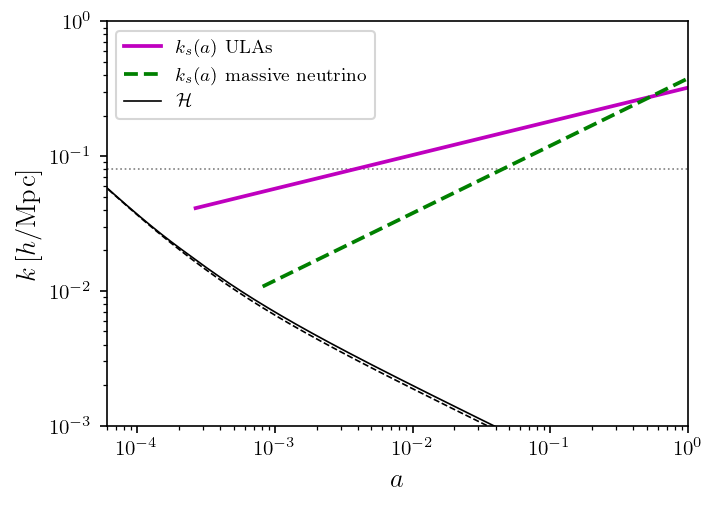

In [11]:
plt.figure(figsize=(5,3.5), dpi=150)

background = chiCDM.get_background() # load background table
a = 1/(background['z']+1) # read redshift
Ha=background['H [1/Mpc]']/(1.+background['z'])
Ha_chi_int=interp1d(a,Ha)

background = nuCDM.get_background() # load background table
a_nu = 1/(background['z']+1) # read redshift
Ha_nu_cosmo=background['H [1/Mpc]']/(1.+background['z'])

plt.axhline(0.08, lw=0.8, color='gray', ls=':')

kJ_ULA_z = interp1d(a,8.4e12 * pow(m_ev/h,1/2) * (a)**0.25)
a_ma = 2.38e-4
a_eq = 1/(1+3781)
plt.loglog(a[a>a_eq],kJ_ULA_z(a)[a>a_eq],'m',label=r'$k_s(a)$ ULAs', lw=1.8)

kJnu_a = interp1d(a,np.sqrt(5/9)* 5.e-2 * (1./0.1) * pow(a,1/2)* np.sqrt(nuCDM.Omega0_m()/0.3))
aNR_nu=1/1890/(mnu)
aNR_nu = 8.12e-04
plt.loglog(a[a>aNR_nu],kJnu_a(a)[a>aNR_nu],'g',label=r'$k_s(a)$ massive neutrino', lw=1.8, ls='--')
print(f'Neutrino kdrop is at {kJnu_a(a)[a>aNR_nu][0]}')
plt.loglog(a,Ha/h,'k',label=r'$\mathcal{H}$', lw = 0.8)
plt.loglog(a_nu,Ha_nu_cosmo/h,'k--', lw = 0.8)

plt.xlim([6.e-5,1])
plt.ylim([1.e-3,1])
plt.legend(fontsize=9)
plt.xscale('log')
plt.xlabel(r'$a$', fontsize=13)
plt.ylabel(r'$k\,[h/\mathrm{Mpc}]$', fontsize=13)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/ks_a_evolution.pdf',bbox_inches='tight')
plt.show()

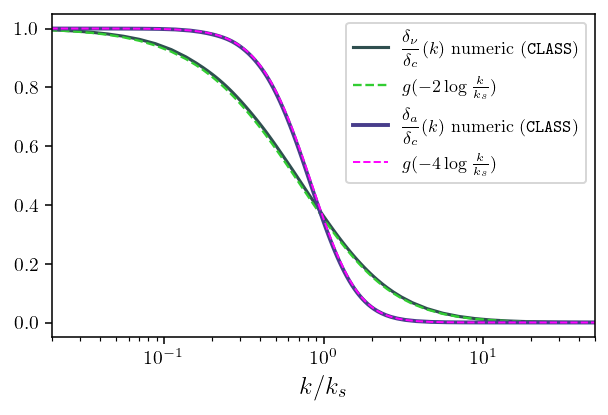

In [13]:
zeval = 0.5

def g_an(t):
    return  1 + 6 * np.exp(-t) * np.cos(np.sqrt(6) * np.exp(-t / 2)) * sici(np.sqrt(6) * np.exp(-t / 2))[1] - 3 * np.exp(-t) * np.pi * np.sin(np.sqrt(6) * np.exp(-t / 2)) + 6 * np.exp(-t) * np.sin(np.sqrt(6) * np.exp(-t / 2)) * sici(np.sqrt(6) * np.exp(-t / 2))[0]


chi_tk_k = chiCDM.get_transfer(z=zeval)
kEval=chi_tk_k['k (h/Mpc)']
T_ratio_ax =chi_tk_k['d_scf']/ chi_tk_k['d_cdm']
kJa =8.4e12 * pow(m_ev/h,1/2) * (1/(1+zeval))**0.25

nu_tk_k = nuCDM.get_transfer(z=zeval)
T_ratio_nu =nu_tk_k['d_ncdm[0]']/ nu_tk_k['d_cdm']
# mnu = Mnu/3
kJnu = np.sqrt(5/9)* 5.e-2 * (mnu/0.1) * pow((1/(1+zeval)),1/2)* np.sqrt(nuCDM.Omega0_m()/0.3)


plt.figure(figsize=(5.,3), dpi=140)

# kJestnu =0.155 * (Mnu/0.3) * pow(0.666,1/2)

plt.plot(kEval/kJnu, T_ratio_nu,'darkslategray', linewidth=1.6,label=r'$\displaystyle\frac{\delta_\nu}{\delta_c}(k)$ numeric ($\texttt{CLASS}$)')
plt.plot(kEval/kJnu, g_an(-2*np.log(kEval/(kJnu))),'limegreen', linestyle='--', linewidth=1.2,label=r'$g(-2\log \frac{k}{k_s})$ ')

plt.plot(kEval/kJa, T_ratio_ax,'darkslateblue', linewidth=2.,label=r'$\displaystyle\frac{\delta_a}{\delta_c}(k)$ numeric ($\texttt{CLASS}$)')


plt.plot(kEval/kJa, g_an(-4*np.log(kEval/(kJa))),'fuchsia', linestyle='--', linewidth=1.,label=r'$g(-4\log \frac{k}{k_s})$')

plt.xscale('log')
plt.xlabel(r'$k/k_s$', fontsize=13)
plt.legend(loc='best', fontsize=9)
plt.xlim([2.e-2,5.e1])
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/lincompare.pdf', bbox_inches='tight')
plt.show()

In [10]:
kk = np.logspace(-3,np.log10(5),200)
chiCDM.set({
    'm_axion': 1.e-20 * _ev_to_HO_,  # in units of H0
})
chiCDM.compute()

Pk_cdm = np.array([chiCDM.pk_lin(k*h,zeval)*h**3 for k in kk])

chiCDM.set({
    'm_axion': 1.e-27 * _ev_to_HO_,  # in units of H0
})
chiCDM.compute()
Pk_ax = np.array([chiCDM.pk_lin(k*h,zeval)*h**3 for k in kk])


Running CLASS version v3.2.0
Computing background
Chose ndf15 as generic_evolver
 -> age = 13.368997 Gyr
 -> conformal age = 13576.578688 Mpc
 -> H0 = 67.810000 km/s/Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
    Scalar field details:
     -> Omega_scf = 0.0344047, wished 0.0344048
Additional scf parameters used: 
n = 1.000000e+00 m_a = 9.974627e-21 eV, f_a/mpl = 4.000000e-01
     -> theta_ini = 1.325642e-02 	 phi_ini = 5.302569e-03 
     -> Exact log10(z_c) = 1.046375e+00 	 f_ede = 9.957242e-02 log10 f_ede = -1.001861e+00
     -> phi(z_c) = 3.197946e-03 
     -> Omega_Lambda = 0.655855, wished 0.655855
 -> radiation/matter equality at z = 3781.415182
    corresponding to conformal time = 101.527424 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0486773       , omega = 0.0223828      
-> Cold Dark Matter               Omega = 0.260972    

0.28262334305262155
0.3164385508916723


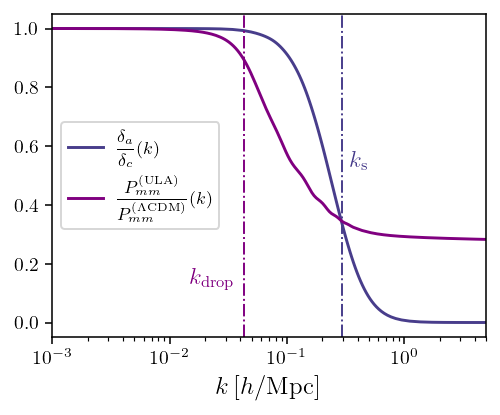

In [35]:
chi_tk_k = chiCDM.get_transfer(z=zeval)

kEval=chi_tk_k['k (h/Mpc)']
d_ax_k=-chi_tk_k['d_scf']
d_cdm_k=-chi_tk_k['d_cdm']
T_ratio_ax =chi_tk_k['d_scf']/ chi_tk_k['d_cdm']

kJest =8.4e12 * pow(1.e-27/h,1/2) * (1/(1+zeval))**0.25
kdropest =5.2e-2 * pow(1.e-27*_ev_to_HO_/1.e6,1/2)

plt.figure(figsize=(4.,3), dpi=140)

plt.axvline(kJest, linewidth=1., color='darkslateblue', linestyle='-.')
plt.text(kJest+5.e-2, 0.55, r'$k_\mathrm{s}$', color='darkslateblue', fontsize=12, ha='left', va='center', rotation=0)
plt.semilogx(kEval, chi_tk_k['d_scf']/chi_tk_k['d_cdm'],'darkslateblue',label=r'$\displaystyle\frac{\delta_a}{\delta_c}(k)$')


plt.axvline(kdropest, linewidth=1., color='purple', linestyle='-.')
plt.text(1.5e-2, 0.15, r'$k_\mathrm{drop}$', color='purple', fontsize=12, ha='left', va='center', rotation=0)
plt.semilogx(kk, Pk_ax/Pk_cdm, 'purple', label=r'$\displaystyle\frac{P_{mm}^{(\mathrm{ULA})}}{P_{mm}^{(\mathrm{\Lambda CDM})}}(k)$')

endratio = Pk_ax[-1]/Pk_cdm[-1]
print(endratio)
# plt.axhline(endratio, label=f'{endratio:.5f}')
fU=0.1
print((1-fU)**2 * np.exp(-6/5*fU*np.log((1+3781)/(1+0.5))))

plt.xlabel(r'$k\,[h/\mathrm{Mpc}]$', fontsize=13)
plt.legend(loc='center left', fontsize=9)

plt.xlim([1.e-3,5])
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/kdrop_vs_ks_ULAs.pdf', bbox_inches='tight')
plt.show()


In [14]:
kk2 = np.logspace(-3,np.log10(5),200)

mnu= 1.
nuCDM = Class()
nuCDM.set(common_settings)
# Fix omega_m = 0.142
omega_nu = mnu/93.14
omega_c = 0.142-0.02238-omega_nu
nuCDM.set({
    'omega_cdm':omega_c,
    'N_ur': 2.0328,
    'N_ncdm':1,
    'm_ncdm':mnu,
    'ncdm_fluid_approximation':1,
})
nuCDM.compute()

Pk_nu = np.array([nuCDM.pk_lin(k*h,zeval)*h**3 for k in kk2])
nuCDM = Class()
nuCDM.set(common_settings)
nuCDM.set({
    'omega_cdm':0.12,
    'N_ur': 2.0328,

})
nuCDM.compute()
Pk_nu_LCDM = np.array([nuCDM.pk_lin(k*h,zeval)*h**3 for k in kk2])


Running CLASS version v3.2.0
Computing background
 fraction of ncdm is 9.860216e-02 
 -> non-cold dark matter species with i=1 has m_i = 1.000000e+00 eV (so m_i / omega_i =9.314329e+01 eV)
 -> non-cold dark matter species with i=1 has m_i = 1.000000e+00 eV (so m_i / omega_i =9.314329e+01 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
Chose ndf15 as generic_evolver
 -> age = 13.784589 Gyr
 -> conformal age = 14182.057004 Mpc
 -> H0 = 67.810000 km/s/Mpc
 -> N_eff = 3.046 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3336.658707
    corresponding to conformal time = 115.787165 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0486773       , omega = 0.0223828      
-> Cold Dark Matter               Omega = 0

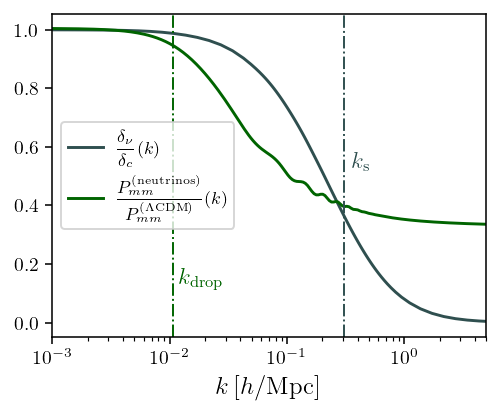

In [ ]:

plt.figure(figsize=(4.,3), dpi=140)

plt.plot(kEval, T_ratio_nu,'darkslategray', label=r'$\displaystyle\frac{\delta_\nu}{\delta_c}(k)$')
plt.semilogx(kk2, Pk_nu/Pk_nu_LCDM, 'darkgreen', label=r'$\displaystyle\frac{P_{mm}^{(\mathrm{neutrinos})}}{P_{mm}^{(\mathrm{\Lambda CDM})}}(k)$')

plt.axvline(kJnu, linewidth=1., color='darkslategray', linestyle='-.')
plt.text(kJnu+5.e-2, 0.55, r'$k_\mathrm{s}$', color='darkslategray', fontsize=12, ha='left', va='center', rotation=0)

kdropnu = 0.0107753
plt.axvline(kdropnu, linewidth=1., color='darkgreen', linestyle='-.')
plt.text(1.2e-2, 0.15, r'$k_\mathrm{drop}$', color='darkgreen', fontsize=12, ha='left', va='center', rotation=0)


plt.xlabel(r'$k\,[h/\mathrm{Mpc}]$', fontsize=13)
plt.legend(loc='center left', fontsize=9)

plt.xlim([1.e-3,5])
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/kdrop_vs_ks_neutrinos.pdf', bbox_inches='tight')
plt.show()


---
counterterm difference

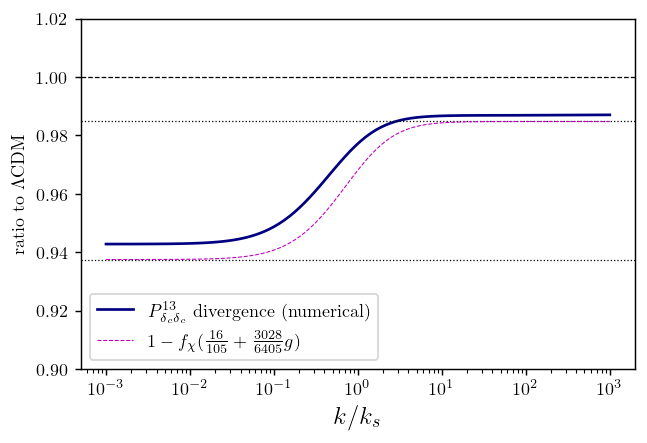

In [ ]:
import sys
sys.path.append('/home/fverdian/class/soundspeed-scripts/numerical-integrals')
from num_kernels import NumKernels

fx=0.1
t_ini = -7
fullt=np.linspace(t_ini,30, 300)
teval=0
kref=1
supprshift=8
p=2
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.0001, p=p, supprshift=supprshift)

eta, val = np.loadtxt('/home/fverdian/class/soundspeed-scripts/figure/UV-Pcc_F3Data.dat', unpack=True)

div_of_eta = interp1d(eta, val, fill_value='extrapolate')


plt.figure(figsize=(5.5, 3.5), dpi=130)

Edsdiv = -61/630/np.pi**2
lim1 = (Edsdiv + 0.1* 286/4725/np.pi**2)
lim2 = (Edsdiv + 0.1* 488/33075/np.pi**2)

kvals = np.logspace(-3,3,100)
plt.plot(kvals,div_of_eta(-2*np.log(kvals))/Edsdiv, 'navy', label=r'$P^{13}_{\delta_c\delta_c}$ divergence (numerical)')

plt.axhline(1, color='k', linestyle='--', linewidth=0.7)
plt.axhline(lim1/Edsdiv, color='k', linestyle=':', linewidth=0.7)
plt.axhline(lim2/Edsdiv, color='k', linestyle=':', linewidth=0.7)

plt.plot(kvals,1-0.1*(16/105 + 3028/6405*nk.g_an(-2*np.log(kvals))), 'm--', linewidth=0.6, label=r'$1-f_\chi(\frac{16}{105} + \frac{3028}{6405}g)$')


plt.legend()
plt.ylim([0.9,1.02])
plt.ylabel(r'ratio to $\Lambda$CDM', fontsize=10)
plt.xscale('log')
plt.xlabel(r'$k/k_s$', fontsize=14)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/Pcc-UV-divergence.pdf', bbox_inches='tight')
plt.show()

-------
Plots of numerical integration with full kernels vs EdS

In [ ]:
ma=27

kref=8.4e12 * pow(pow(10,-ma)/0.67,1/2) * 0.666**0.25
fx=0.1

k, dcdc22, dcdc22_EdS, dcTc22, dcTc22_EdS, dcdx22, dcdx22_EdS, dcTx22, dcTx22_EdS, dxdx22, dxdx22_EdS, PL_cc, TL_x =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P22-ma{ma}p0-fx0p1-N16000-p2.txt', unpack=True)[:,:70]

k, dcdc13, dcdc13_EdS, dcTc13, dcTc13_EdS, dcdx13, dcdx13_EdS, dcTx13, dcTx13_EdS, dxdx13, dxdx13_EdS, PL_cc, TL_x, dcdx_IR  =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P13-ma{ma}p0-fx0p1-N16000-p2.txt', unpack=True)[:,:70]

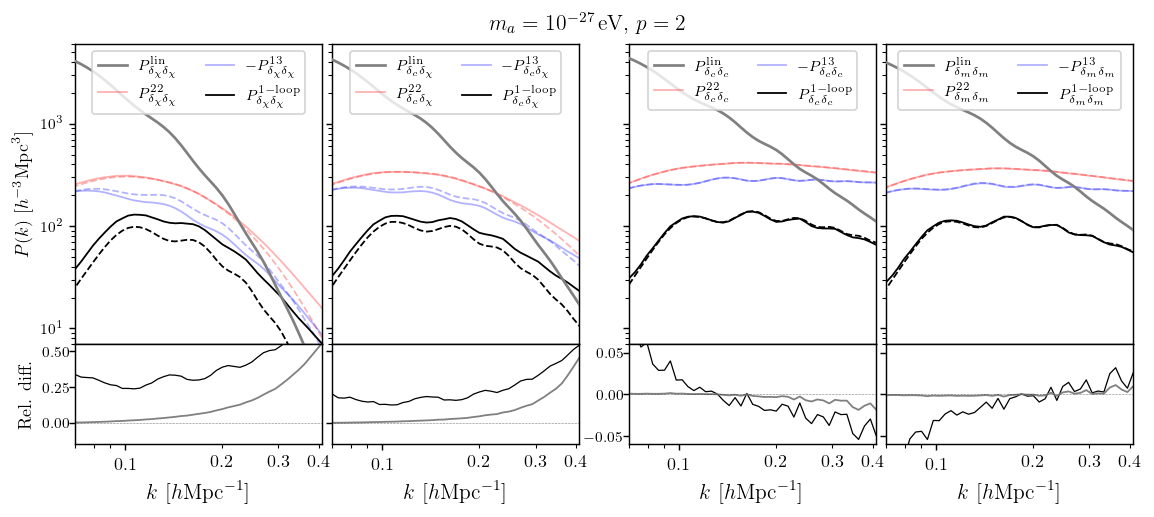

In [3]:
import matplotlib.ticker as ticker

fig, axs = plt.subplots(2, 5, figsize=(10.5, 4.), dpi=130, gridspec_kw={'height_ratios': [3, 1],'width_ratios': [1,1,0.12,1, 1], 'hspace': 0.0, 'wspace':0.05},)

# ------ delta_chi delta_chi
ax = axs[0,0]
ax.plot(k, PL_cc*TL_x*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_\chi\delta_\chi}$', zorder=4)
ax.plot(k, dxdx22, 'r', label=r'$P^{22}_{\delta_\chi\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, dxdx22_EdS, 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -dxdx13, 'b', label=r'$-P^{13}_{\delta_\chi\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, -dxdx13_EdS, 'b--', linewidth=1, alpha=0.3)
ax.plot(k, (dxdx22+dxdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_\chi\delta_\chi}$', linewidth=1)
ax.plot(k, (dxdx22_EdS+dxdx13_EdS), 'k--', linewidth=1)
ax.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=10)
# Lower panel (relative differences)
ax = axs[1,0]
relative_diff_1l_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (dxdx22 + dxdx13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (PL_cc*TL_x*TL_x+ dxdx22 + dxdx13)
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')
ax.set_ylabel('Rel. diff.', fontsize=10)

# ------ delta_c delta_chi
ax = axs[0,1]
ax.plot(k, PL_cc*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_\chi}$', zorder=4)
ax.plot(k, dcdx22, 'r', label=r'$P^{22}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, dcdx22_EdS, 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -dcdx13, 'b', label=r'$-P^{13}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, -dcdx13_EdS, 'b--', linewidth=1, alpha=0.3)
ax.plot(k, (dcdx22+dcdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_\chi}$', linewidth=1)
ax.plot(k, (dcdx22_EdS+dcdx13_EdS), 'k--', linewidth=1)
# Lower panel (relative differences)
ax = axs[1,1]
relative_diff_1l_total = ((dcdx22 + dcdx13) - (dcdx22_EdS + dcdx13_EdS)) / (dcdx22 + dcdx13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = (PL_cc*TL_x+ (dcdx22 + dcdx13)) / (PL_cc*TL_x+ dcdx22_EdS + dcdx13_EdS)-1
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

# ------ delta_c delta_c
ax = axs[0,3]
ax.plot(k, PL_cc, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_c}$', zorder=4)
ax.plot(k, dcdc22, 'r', label=r'$P^{22}_{\delta_c\delta_c}$', linewidth=1, alpha=0.3)
ax.plot(k, dcdc22_EdS, 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -dcdc13, 'b', label=r'$-P^{13}_{\delta_c\delta_c}$', linewidth=1, alpha=0.3)
ax.plot(k, -dcdc13_EdS, 'b--', linewidth=1, alpha=0.3)
ax.plot(k, (dcdc22+dcdc13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_c}$', linewidth=1)
ax.plot(k, (dcdc22_EdS+dcdc13_EdS), 'k--', linewidth=1)
# Lower panel (relative differences)
ax = axs[1,3]
relative_diff_1l_total = ((dcdc22 + dcdc13) - (dcdc22_EdS + dcdc13_EdS)) / (dcdc22 + dcdc13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = ((dcdc22 + dcdc13) - (dcdc22_EdS + dcdc13_EdS)) / (PL_cc+ dcdc22 + dcdc13)
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

# ------ delta_m delta_m
ax = axs[0,4]
ax.plot(k, PL_cc*mm(1,TL_x, TL_x**2), 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)
ax.plot(k, mm(dcdc22,dcdx22,dxdx22), 'r', label=r'$P^{22}_{\delta_m\delta_m}$', linewidth=1, alpha=0.3)
ax.plot(k, mm(dcdc22_EdS,dcdx22_EdS,dxdx22_EdS) , 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -mm(dcdc13,dcdx13,dxdx13), 'b', label=r'$-P^{13}_{\delta_m\delta_m}$', linewidth=1, alpha=0.3)
ax.plot(k, -mm(dcdc13_EdS,dcdx13_EdS,dxdx13_EdS), 'b--', linewidth=1, alpha=0.3)
ax.plot(k, mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_m\delta_m}$', linewidth=1)
ax.plot(k, mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS), 'k--', linewidth=1)
# Lower panel (relative differences)
ax = axs[1,4]
relative_diff_1l_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (dxdx22 + dxdx13)
relative_diff_1l_total = mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS)/mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13)-1
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = (mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS) - mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13))/ (PL_cc*mm(1,TL_x, TL_x**2)+mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13))
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')


for ax in axs.flat:
    ax.set_xscale('log')
    ax.set_xlim([0.07,0.41])
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}"))
    ax.xaxis.set_minor_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}" if x>0.09 else ""))

for i in [0,1,3,4]:
    axs[0,i].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    axs[0,i].legend(fontsize=8, loc='upper center', ncol=2)
    axs[0,i].set_ylim([7e0,6.e3])
    axs[0,i].set_yscale('log')
    axs[1,i].axhline(y=0., linestyle=':', color='k', linewidth=0.3)
    axs[1,i].set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)

for i in [0,1]:
    axs[1,i].set_ylim([-0.15,0.55])
for i in [3,4]:
    axs[1,i].set_ylim([-0.06,0.06])

for com in [(0,1),(1,1),(0,4),(1,4),(0,3)]:
    axs[com].tick_params(axis='y', labelleft=False)
axs[0, 2].axis('off')  # Turn off the top blank subplot
axs[1, 2].axis('off')  # Turn off the bottom blank subplot

axs[0,0].tick_params(axis='y',labelsize=8)  # Y-axis tick labels inside
axs[1,0].tick_params(axis='y',labelsize=8, pad=-0.1)  # Y-axis tick labels inside
axs[1,3].tick_params(axis='y',labelsize=8, pad=-0.1,)  # Y-axis tick labels inside

fig.text(0.5, 0.92, r'$m_a=10^{-'+str(ma)+r'}\,\mathrm{eV}$, $p=2$', ha='center', va='center', fontsize=12)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_m27_full.pdf', bbox_inches='tight')

plt.show()

In [3]:
k, dcdc22, dcdc22_EdS, dcTc22, dcTc22_EdS, dcdx22, dcdx22_EdS, dcTx22, dcTx22_EdS, dxdx22, dxdx22_EdS, PL_cc, TL_x =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P22-ma27p0-fx0p02-N6000-p2.txt', unpack=True)[:,:70]
k, dcdc13, dcdc13_EdS, dcTc13, dcTc13_EdS, dcdx13, dcdx13_EdS, dcTx13, dcTx13_EdS, dxdx13, dxdx13_EdS, PL_cc, TL_x, dcdx_IR  =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P13-ma27p0-fx0p02-N6000-p2.txt', unpack=True)[:,:70]
fx=0.02

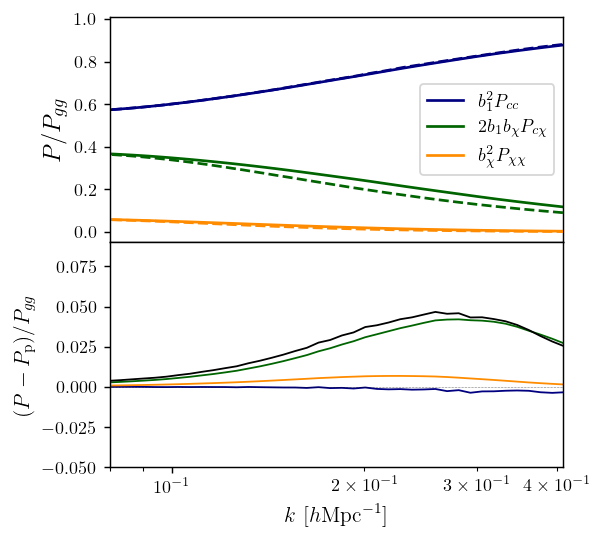

In [6]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4.5, 4.5), dpi=130, gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.0})

# Upper panel
bc = 1.5
bx = 0.5

bc2_contr = (bc**2)*(PL_cc +dcdc22 + dcdc13)
bcbx_contr = (2*bc*bx)*(TL_x*PL_cc + dcdx22 + dcdx13)
bx2_contr = (bx**2)*(TL_x**2 * PL_cc +dxdx22 + dxdx13)
Pgg = bc2_contr + bcbx_contr + bx2_contr

bc2_contr_EdS = (bc**2)*(PL_cc +dcdc22_EdS + dcdc13_EdS)
bcbx_contr_EdS = (2*bc*bx)*(TL_x*PL_cc + dcdx22_EdS + dcdx13_EdS)
bx2_contr_EdS = (bx**2)*(TL_x**2 * PL_cc +dxdx22_EdS + dxdx13_EdS)
Pgg_EdS = bc2_contr_EdS + bcbx_contr_EdS + bx2_contr_EdS

ax1.plot(k, bc2_contr/Pgg, 'navy',linewidth=1.5, label=r'$b_1^2 P_{cc}$')
ax1.plot(k, bc2_contr_EdS/Pgg, 'navy',linestyle='--', linewidth=1.5, zorder=4)


ax1.plot(k, bcbx_contr/Pgg, 'darkgreen',linewidth=1.5, label=r'$2b_1b_\chi P_{c\chi}$')
ax1.plot(k, bcbx_contr_EdS/Pgg, 'darkgreen',linestyle='--', linewidth=1.5, zorder=4)

ax1.plot(k, bx2_contr/Pgg, 'darkorange',linewidth=1.5,label=r'$b_\chi^2 P_{\chi\chi}$')
ax1.plot(k, bx2_contr_EdS/Pgg, 'darkorange', linestyle='--', linewidth=1.5, zorder=4)


ax1.legend(fontsize=10, loc='best')
ax1.set_ylabel(r'$P/P_{gg}$', fontsize=14)

ax1.tick_params(axis='x', labelbottom=False)

ax2.plot(k, (bc2_contr-bc2_contr_EdS)/Pgg, 'navy', linewidth=1., linestyle='-')

ax2.plot(k, (bcbx_contr-bcbx_contr_EdS)/Pgg, 'darkgreen', linewidth=1., linestyle='-')
ax2.plot(k, (bx2_contr-bx2_contr_EdS)/Pgg, 'darkorange', linewidth=1., linestyle='-')

ax2.plot(k, (Pgg-Pgg_EdS)/Pgg, 'k', linewidth=1., linestyle='-')


ax2.axhline(y=0., linestyle=':', color='k', linewidth=0.3)

ax2.set_ylim([-0.05,0.09])
ax2.set_xscale('log')
ax2.set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_ylabel(r'$(P-P_\mathrm{p})/P_{gg}$', fontsize=12)


ax1.set_xlim([0.08, 0.41])
ax2.set_xlim([0.08, 0.41])

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/Pgg_prescription_breakdown.pdf', bbox_inches='tight')

plt.show()

Fitted value for c_cchi: -5.8605444282648085 and c_cc: -0.7447352240478574


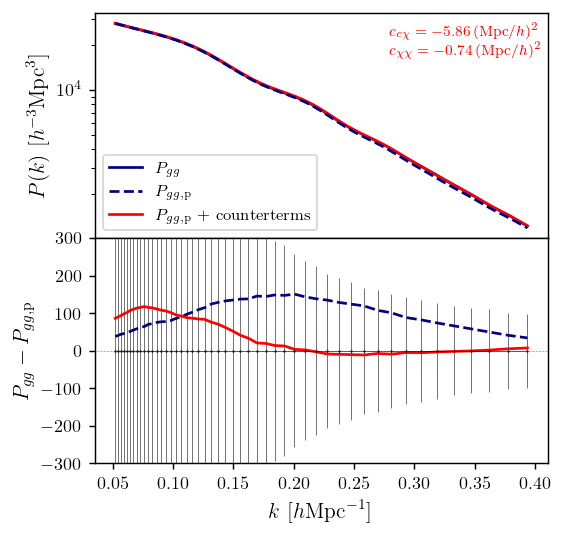

In [ ]:
from scipy.optimize import curve_fit

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4.5, 4.5), dpi=130, gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.0})

# Upper panel
bc = 1.5
bx = 0.5


bc2_contr = (bc**2)*(PL_cc +dcdc22 + dcdc13)
bcbx_contr = (2*bc*bx)*(TL_x*PL_cc + dcdx22 + dcdx13)
bx2_contr = (bx**2)*(TL_x**2 * PL_cc +dxdx22 + dxdx13)
Pgg = bc2_contr + bcbx_contr + bx2_contr

bc2_contr_EdS = (bc**2)*(PL_cc +dcdc22_EdS + dcdc13_EdS)
bcbx_contr_EdS = (2*bc*bx)*(TL_x*PL_cc + dcdx22_EdS + dcdx13_EdS)
bx2_contr_EdS = (bx**2)*(TL_x**2 * PL_cc +dxdx22_EdS + dxdx13_EdS)
Pgg_EdS = bc2_contr_EdS + bcbx_contr_EdS + bx2_contr_EdS

kmask = (k<0.4) & (k>0.05)

ax1.plot(k[kmask], Pgg[kmask], 'navy',linewidth=1.5, label=r'$P_{gg}$')
ax1.plot(k[kmask], Pgg_EdS[kmask], 'navy',linestyle='--', linewidth=1.5, zorder=4, label=r'$P_{gg,\mathrm{p}}$ ')


def func(k, ccx, cxx):
    return (Pgg_EdS[kmask] - ccx * k[kmask]**2 *TL_x[kmask]* PL_cc[kmask]- cxx * k[kmask]**2  *TL_x[kmask]**2 * PL_cc[kmask])


# ERRORBARS PART
Cfull = np.loadtxt('/home/fverdian/class/soundspeed-scripts/numerical-integrals/cutofftests/C_024Q_ngc_z3.txt')
kboss, _, _, _ =  np.loadtxt('/home/fverdian/class/soundspeed-scripts/numerical-integrals/cutofftests/pk_boss_ngc_z3_fkp.txt', unpack=True)
CQ0Q0 = np.diag(Cfull[-78:,-78:])
CQ0_k = interp1d(kboss, CQ0Q0, kind='linear')(k[kmask])

# Fit the curve
popt, pcov = curve_fit(func, k, Pgg[kmask], sigma=CQ0_k)

# Extract the fitted c value
ccx_fitted = popt[0]
cxx_fitted = popt[1]

# Print the fitted c value
print(f"Fitted value for c_cchi: {ccx_fitted} and c_cc: {cxx_fitted}")

# Plot the fitted curve
ax1.plot(k[kmask], func(k, ccx_fitted,cxx_fitted), 'red', linestyle='-', linewidth=1.5, label=r'$P_{gg,\mathrm{p}}$ + counterterms')

ax1.legend(fontsize=9, loc='lower left')

ax1.text(0.65, 0.95, r'$c_{c\chi}='+f'{ccx_fitted:.2f}'+r'\,(\mathrm{Mpc}/h)^2$'+'\n'+r'$c_{\chi\chi}='+f'{cxx_fitted:.2f}'+r'\,(\mathrm{Mpc}/h)^2$', transform=ax1.transAxes, ha='left', va='top', fontsize=8, color='red')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

reldifforig = (Pgg-Pgg_EdS)
reldifffitted = (func(k, ccx_fitted,cxx_fitted) - Pgg[kmask])


ax2.errorbar(k[kmask], np.zeros_like(CQ0_k), yerr = np.sqrt(CQ0_k), color='k', linewidth=0.3, marker='o', markersize=0.3, label=r'Fitted curve')


ax2.plot(k[kmask], reldifforig[kmask], 'navy', linestyle='--', linewidth=1.5, label=r'Fitted curve')
ax2.plot(k[kmask], reldifffitted, 'r', linestyle='-', linewidth=1.5, label=r'Fitted curve')
ax2.axhline(y=0., linestyle=':', color='k', linewidth=0.3)

ax2.set_ylim([-300,300])
ax2.set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_ylabel(r'$P_{gg}-P_{gg,\mathrm{p}}$', fontsize=12)

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/Pgg_prescription_countertermfit.pdf', bbox_inches='tight')

plt.show()

In [ ]:
h = 0.67810
_H0_ = 3.336e-04 * h
_ev_to_HO_ = 1.56e29 / _H0_
common_settings = {'omega_b': 0.0223828, 'h': h, 'z_reio': 7.6711, 'YHe': 0.25, 'perturbations_verbose': 1, 'background_verbose': 3, 'output': 'mTk, vTk, mPk', 'P_k_max_1/Mpc': 10, 'z_max_pk': 1000, 'format': 'class'}

chiCDM = Class()
chiCDM.set(common_settings)
m_ev = 1.e-27
fx = 0.06
chiCDM.set({'omega_cdm': 0.12, 'scf_potential': 'axion', 'n_axion': 1, 'f_axion': 0.4, 'Omega_scf': ((fx/(1-fx))*(0.12+0.02238))/h/h, 'm_axion': m_ev * _ev_to_HO_, 'tol_shooting_deltax': 1e-4, 'tol_shooting_deltaF': 1e-4, 'scf_parameters': '0.05,0.0', 'scf_tuning_index': 0, 'scf_evolve_as_fluid': 'yes', 'scf_evolve_like_axionCAMB': 'yes', 'threshold_scf_fluid_m_over_H': 3, 'do_shooting': 'yes', 'do_shooting_scf': 'yes', 'scf_has_perturbations': 'yes', 'use_big_theta_scf': 'no', 'use_delta_scf_over_1plusw': 'no', 'attractor_ic_scf': 'no', 'evolver': 0})
chiCDM.compute()

pureCDM = Class()
pureCDM.set(common_settings)
pureCDM.set({'N_ur': 3.046, 'omega_cdm':0.12,})
pureCDM.compute()

nuCDM = Class()
nuCDM.set(common_settings)
Mnu= 0.6
nuCDM.set({'N_ur': 2.0328, 'N_ncdm': 3, 'm_ncdm': f'{Mnu/3},{Mnu/3},{Mnu/3}', 'ncdm_fluid_approximation': 1})
nuCDM.compute()

0.41522739926869984